# PLOTS WEEK-1


In [4]:
import os
import sys
import warnings
import scipy as scipy
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
#import shapely.geometry as shpl
import pygrib
from mpl_toolkits.basemap import Basemap, cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmocean
from colour import Color
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.dates as mdates
import rioxarray

import cartopy.io.shapereader as shpreader


from shapely.ops import unary_union
from shapely.geometry import MultiPolygon

In [ ]:
def get_era5_one_week(year, week):
    """
    Get the weekly data for a all variables from the ERA5 dataset (solar radiation, temperature, precipitation, wind speed (u,v)).
    use xarray to read the data files and extract the relevant time period.

    Parameters
    ----------
    file_var : str
        The path to the ERA5 data file for the variable.
    file_gh : str
        The path to the ERA5 data file for the geopotential height.

    Returns
    -------
    xr.Dataset
        The dataset containing the weekly data for the specified variables.
    """

    list_var = ['2t', 'tp', '100u', '100v', 'ssr', 'z']

    ds_var = {}

    hist_var = {}

    # Read the data using xarray 
    for var in list_var:
        file_var = f'era5/era5_{var}_{year}week{week}.grib'
        ds_var[var] = xr.open_dataset(file_var)

    for var in list_var:
        file = f'era5/era5_{var}_historical.grib'

    return ds_var, hist_var

In [22]:
week=39
year=2025
data_week = get_era5_one_week(year, week)

In [124]:
data_week['ssr']

<xarray.Dataset> Size: 24MB
Dimensions:     (time: 15, step: 12, latitude: 153, longitude: 221)
Coordinates:
    number      int32 4B ...
  * time        (time) datetime64[ns] 120B 2025-09-19T18:00:00 ... 2025-09-26...
  * step        (step) timedelta64[ns] 96B 01:00:00 02:00:00 ... 12:00:00
    surface     float64 8B ...
  * latitude    (latitude) float64 1kB 73.0 72.75 72.5 72.25 ... 35.5 35.25 35.0
  * longitude   (longitude) float64 2kB -15.0 -14.75 -14.5 ... 39.5 39.75 40.0
    valid_time  (time, step) datetime64[ns] 1kB ...
Data variables:
    ssr         (time, step, latitude, longitude) float32 24MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-02T11:47 GRIB to CDM+CF via cfgrib-0.9.1...

In [170]:
def maps_weekly(var, data_week):
    """
    Plot the weekly map for a given variable from the ERA5 dataset.
    Parameters
    ----------
    var : str
        The variable to plot. Options are '2t', 'tp', 'wind', 'ssr', 'z'.
    """


    # Plot the data
    plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
   
    if var == '2t':

        data_mean = data_week['2t'].mean(dim='time') - 273.15  # Convert from Kelvin to Celsius
        maxval = int(np.nanmax(np.abs(data_mean.to_dataarray()))) + 1
        cmap = 'coolwarm'
        levels = np.arange(-maxval, maxval, 2)
        label = 'Temperature (°C)'

    elif var == 'tp':
        data = data_week['tp']
        # For total weekly accumulated precipitation:
        # Sum over all time and step dimensions to get total accumulation
        data_mean = data.sum(dim=['time', 'step']) * 1000  # Convert to mm
        
        cmap = cmocean.cm.rain
        maxval = max(1, int(np.nanmax(np.abs(data_mean.to_dataarray()))) + 1)
        levels = np.arange(0, 140, 10)  # Use larger intervals for total accumulation
        label = 'Total Weekly Precipitation (mm)'
    
    elif var == 'wind':
        u_data = data_week['100u']
        v_data = data_week['100v']
        
        # Get the actual data variables (assuming they're the first/main variable in each dataset)
        u_var = list(u_data.data_vars)[0]
        v_var = list(v_data.data_vars)[0]
        
        u = u_data[u_var]
        v = v_data[v_var]
        
        # Calculate wind speed magnitude from u and v components
        wind_speed = np.sqrt(u**2 + v**2)
        data_mean = wind_speed.mean(dim='time')
        maxval = int(np.nanmax(data_mean.to_numpy())) + 1
        cmap = cmocean.cm.speed  # Use speed colormap for wind
        levels = np.arange(0, maxval, 1)  # Wind speed is always positive
        label = 'Wind Speed (m/s)'

    elif var == 'ssr':
        data = data_week['ssr'] /3600  # Convert from J/m² to W/m² (assuming 1 hour steps)
        # Simply average the accumulated values over time and step
        data_mean = data.mean(dim=['time', 'step']) 
                
        cmap = cmocean.cm.solar
        maxval = max(1, int(np.nanmax(np.abs(data_mean.to_dataarray()))) + 1)
        levels = np.arange(0, maxval, 20)  # Use larger intervals for W/m²
        label = 'Average Net Incoming Solar Irradiance (W/m²)'
        
    elif var == 'z':
        cmap = cmocean.cm.deep
        maxval = int(np.nanmax(np.abs(data_mean.to_dataarray()))) + 1
        levels = np.arange(0, maxval, 200)
        label = 'Geopotential Height (m)'
    else:
        raise ValueError("Invalid variable. Options are '2t', 'tp', 'wind', 'ssr', 'z'.")

    lon = data_mean['longitude']
    lat = data_mean['latitude']
    lon2d, lat2d = np.meshgrid(lon, lat)



    if var=='wind':
        cf = ax.contourf(lon2d, lat2d, data_mean, levels=levels, cmap=cmap, extend='max', transform=ccrs.PlateCarree())
    else:
        cf = ax.contourf(lon2d, lat2d, data_mean.to_dataarray()[0,:,:], levels=levels, cmap=cmap, extend='both', transform=ccrs.PlateCarree())
    plt.colorbar(cf, ax=ax, orientation='vertical', label=label)
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_title(f'{label} - Week {week} {year}')
    plt.show()

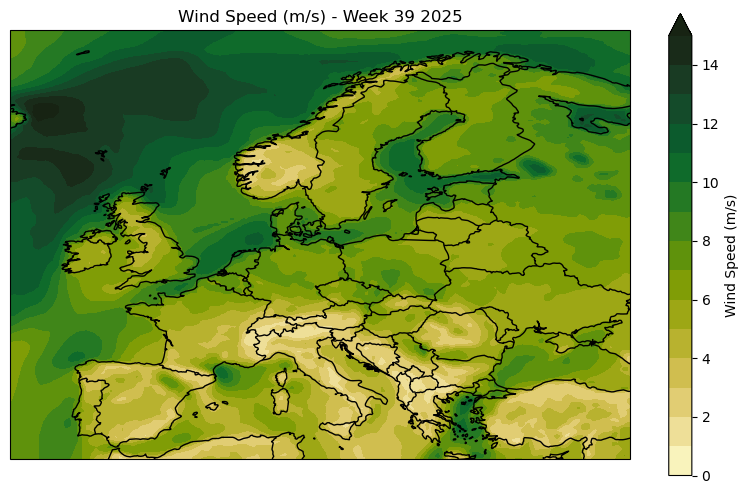

In [167]:
maps_weekly('wind', data_week)

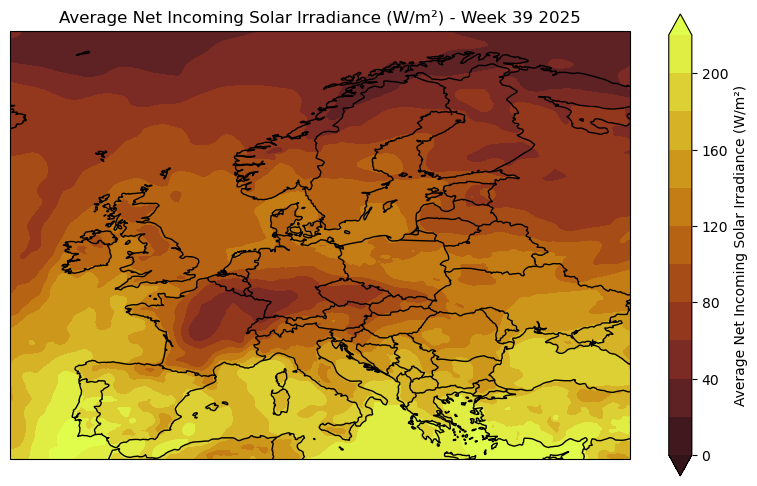

In [171]:
maps_weekly('ssr', data_week)

(1, 153, 221)


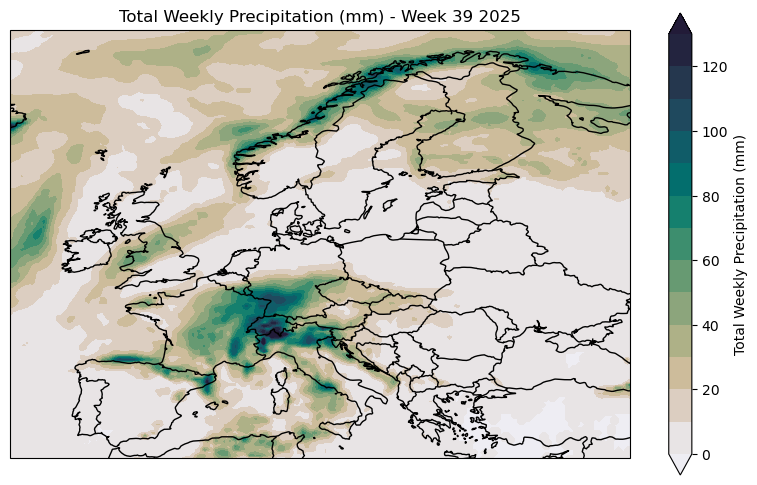

In [165]:
maps_weekly('tp', data_week)

<xarray.Dataset> Size: 138kB
Dimensions:    (latitude: 153, longitude: 221)
Coordinates:
    number     int32 4B ...
    step       timedelta64[ns] 8B ...
    surface    float64 8B ...
  * latitude   (latitude) float64 1kB 73.0 72.75 72.5 72.25 ... 35.5 35.25 35.0
  * longitude  (longitude) float64 2kB -15.0 -14.75 -14.5 ... 39.5 39.75 40.0
Data variables:
    t2m        (latitude, longitude) float32 135kB 1.482 1.53 ... 26.04 26.24


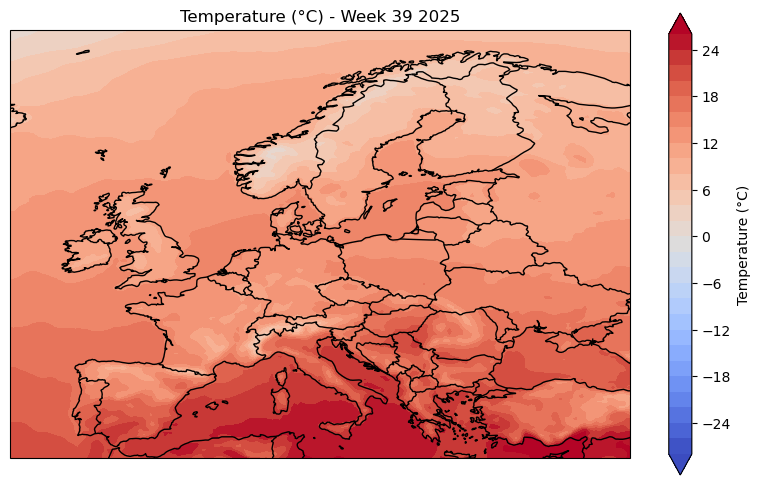

In [135]:
maps_weekly('2t', data_week)